In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np


In [2]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30

dataset_dir = "C:/Users\Sujal Pal\OneDrive\Desktop/New Deep Learning\CNN/archive (1)"

In [3]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 4260 files belonging to 2 classes.
Using 3408 files for training.
Found 4260 files belonging to 2 classes.
Using 852 files for validation.


In [4]:
class_names = train_dataset.class_names
print("Class Names:", class_names)

Class Names: ['Anemic', 'Non-anemic']


In [5]:
import os
class_counts = {name: len(os.listdir(os.path.join(dataset_dir, name))) for name in class_names}
print("Class Counts:", class_counts)
total = sum(class_counts.values())
weight_for_0 = total / (2 * class_counts[class_names[0]])
weight_for_1 = total / (2 * class_counts[class_names[1]])

class_weights = {
    0: weight_for_0,
    1: weight_for_1
}

print("Class Weights:", class_weights)

Class Counts: {'Anemic': 2562, 'Non-anemic': 1698}
Class Weights: {0: 0.8313817330210773, 1: 1.254416961130742}


In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)


In [8]:
model = models.Sequential([

    layers.Input(shape=(128,128,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,177 (12.61 MB)

 Trainable params: 3,305,473 (12.61 MB)

 Non-trainable params: 704 (2.75 KB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)


In [12]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    class_weight=class_weights
)


Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5440 - loss: 1.0226 - precision: 0.4431 - recall: 0.6027

107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 258ms/step - accuracy: 0.5648 - loss: 0.8327 - precision: 0.4589 - recall: 0.6088 - val_accuracy: 0.4789 - val_loss: 0.6953 - val_precision: 0.4411 - val_recall: 0.8615 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5967 - loss: 0.7195 - precision: 0.4901 - recall: 0.6727

107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.6053 - loss: 0.7009 - precision: 0.4978 - recall: 0.6649 - val_accuracy: 0.5340 - val_loss: 0.6876 - val_precision: 0.4637 - val_recall: 0.6371 - learning_rate: 0.0010
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.6295 - loss: 0.6682 - precision: 0.5309 - recall: 0.6729

107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.6347 - loss: 0.6620 - precision: 0.5268 - recall: 0.6754 - val_accuracy: 0.5857 - val_loss: 0.6641 - val_precision: 0.5082 - val_recall: 0.6898 - learning_rate: 0.0010
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.6303 - loss: 0.6502 - precision: 0.5186 - recall: 0.6653

107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 244ms/step - accuracy: 0.6235 - loss: 0.6575 - precision: 0.5158 - recall: 0.6574 - val_accuracy: 0.6385 - val_loss: 0.6143 - val_precision: 0.5546 - val_recall: 0.7452 - learning_rate: 0.0010
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - accuracy: 0.6502 - loss: 0.6193 - precision: 0.5414 - recall: 0.7091 - val_accuracy: 0.6385 - val_loss: 0.6155 - val_precision: 0.5474 - val_recall: 0.8476 - learning_rate: 0.0010
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.6532 - loss: 0.6120 - precision: 0.5446 - recall: 0.7083 - val_accuracy: 0.5469 - val_loss: 0.7662 - val_precision: 0.4820 - val_recall: 0.9280 - learning_rate: 0.0010
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 244ms/step - accuracy: 0.6561 - loss: 0.6095 - precision: 0.5484 - recall: 0.6986 - val_accuracy: 0.5423 - val_loss: 0.7592 - val_precision: 0.4801 - val_recall: 0.9695 - learning_rate: 0.0010
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accurac

...

107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 234ms/step - accuracy: 0.7805 - loss: 0.4548 - precision: 0.6926 - recall: 0.7921 - val_accuracy: 0.8005 - val_loss: 0.4169 - val_precision: 0.7247 - val_recall: 0.8532 - learning_rate: 9.0000e-05
Epoch 22/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - accuracy: 0.7796 - loss: 0.4456 - precision: 0.6903 - recall: 0.7951 - val_accuracy: 0.7864 - val_loss: 0.4337 - val_precision: 0.7425 - val_recall: 0.7590 - learning_rate: 9.0000e-05
Epoch 23/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 245ms/step - accuracy: 0.7955 - loss: 0.4306 - precision: 0.7111 - recall: 0.8063 - val_accuracy: 0.8016 - val_loss: 0.4234 - val_precision: 0.7264 - val_recall: 0.8532 - learning_rate: 9.0000e-05
Epoch 24/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8123 - loss: 0.4178 - precision: 0.7300 - recall: 0.8257

107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - accuracy: 0.8008 - loss: 0.4320 - precision: 0.7173 - recall: 0.8123 - val_accuracy: 0.8110 - val_loss: 0.4000 - val_precision: 0.7463 - val_recall: 0.8393 - learning_rate: 9.0000e-05
Epoch 25/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - accuracy: 0.7972 - loss: 0.4230 - precision: 0.7128 - recall: 0.8093 - val_accuracy: 0.8016 - val_loss: 0.4218 - val_precision: 0.7222 - val_recall: 0.8643 - learning_rate: 9.0000e-05
Epoch 26/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8077 - loss: 0.4111 - precision: 0.7356 - recall: 0.8134

107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - accuracy: 0.8055 - loss: 0.4170 - precision: 0.7223 - recall: 0.8190 - val_accuracy: 0.8146 - val_loss: 0.3850 - val_precision: 0.7506 - val_recall: 0.8421 - learning_rate: 9.0000e-05
Epoch 27/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8086 - loss: 0.4085 - precision: 0.7217 - recall: 0.8242

107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - accuracy: 0.8099 - loss: 0.4127 - precision: 0.7289 - recall: 0.8205 - val_accuracy: 0.8439 - val_loss: 0.3590 - val_precision: 0.8081 - val_recall: 0.8283 - learning_rate: 9.0000e-05
Epoch 28/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - accuracy: 0.8125 - loss: 0.4005 - precision: 0.7330 - recall: 0.8212 - val_accuracy: 0.8099 - val_loss: 0.4042 - val_precision: 0.7625 - val_recall: 0.8006 - learning_rate: 9.0000e-05
Epoch 29/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - accuracy: 0.8137 - loss: 0.3988 - precision: 0.7303 - recall: 0.8325 - val_accuracy: 0.8439 - val_loss: 0.3733 - val_precision: 0.7908 - val_recall: 0.8587 - learning_rate: 9.0000e-05
Epoch 30/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8226 - loss: 0.3723 - precision: 0.7462 - recall: 0.8277

107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 233ms/step - accuracy: 0.8201 - loss: 0.3900 - precision: 0.7433 - recall: 0.8272 - val_accuracy: 0.8545 - val_loss: 0.3541 - val_precision: 0.7912 - val_recall: 0.8920 - learning_rate: 9.0000e-05


In [15]:
def plot_history(history):
    plt.figure(figsize=(15,10))

    plt.subplot(2,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(2,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss")

    plt.subplot(2,2,3)
    plt.plot(history.history['precision'], label='Train Precision')
    plt.plot(history.history['val_precision'], label='Val Precision')
    plt.legend()
    plt.title("Precision")

    plt.subplot(2,2,4)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.legend()
    plt.title("Recall")

    plt.tight_layout()
    plt.show()

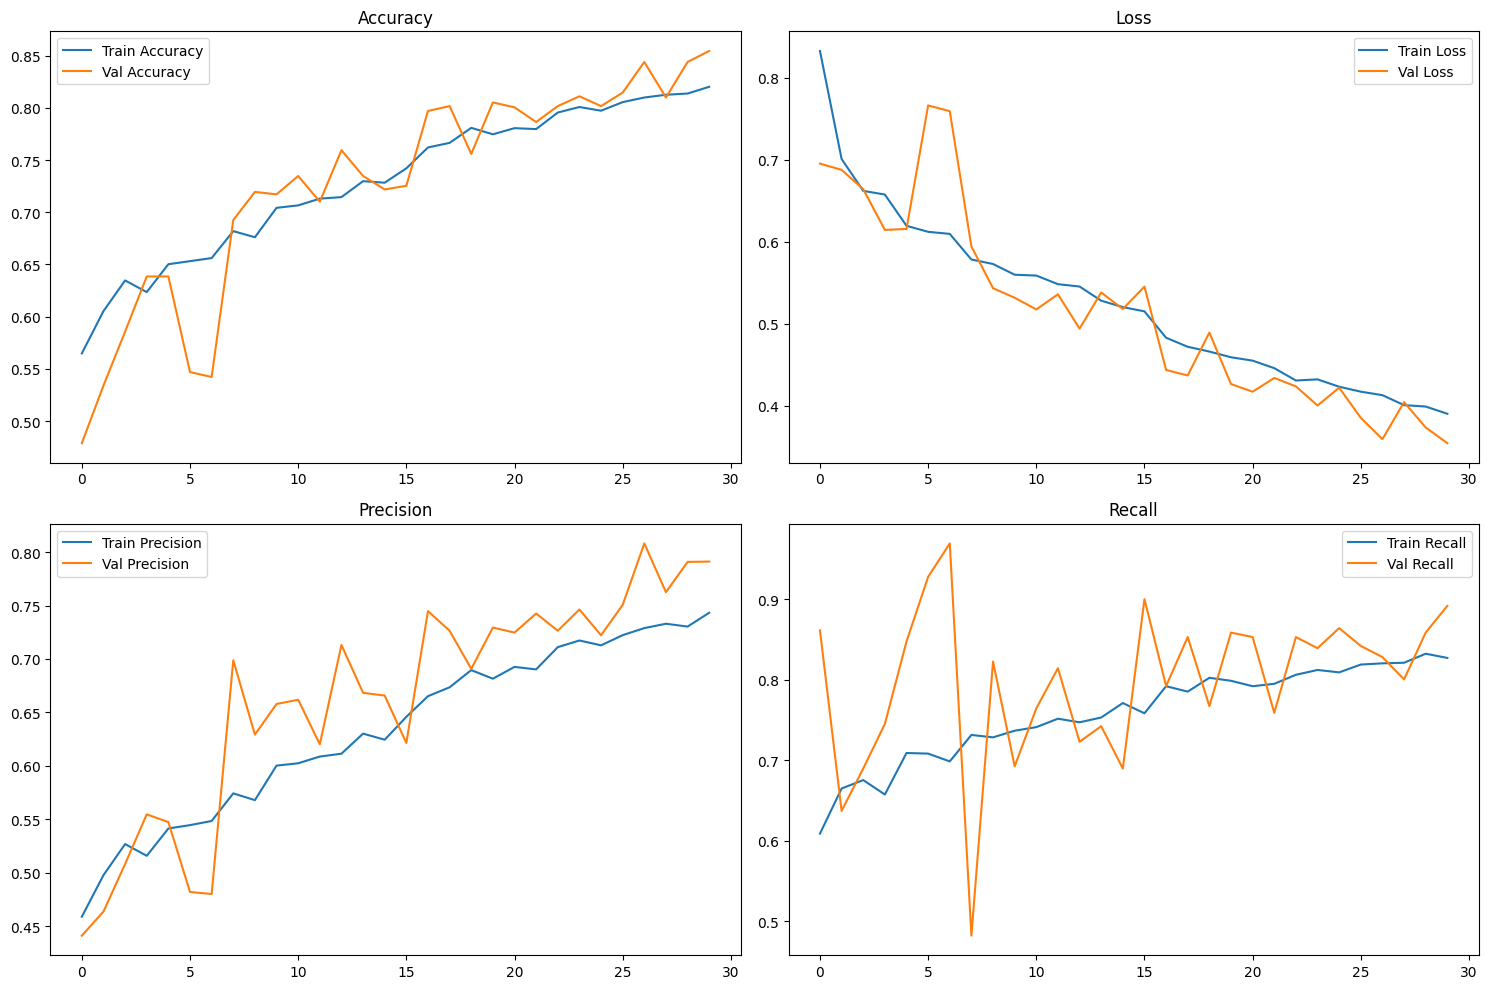

In [16]:
plot_history(history)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━

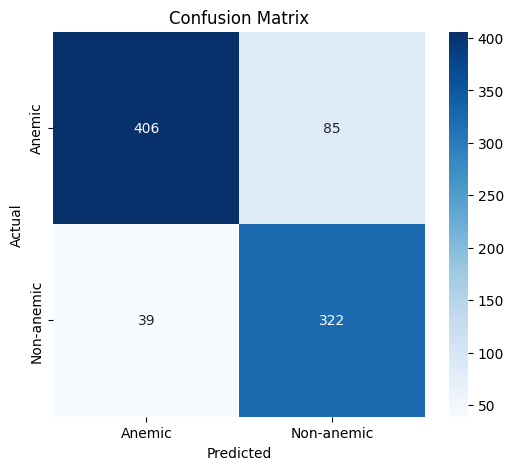

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━

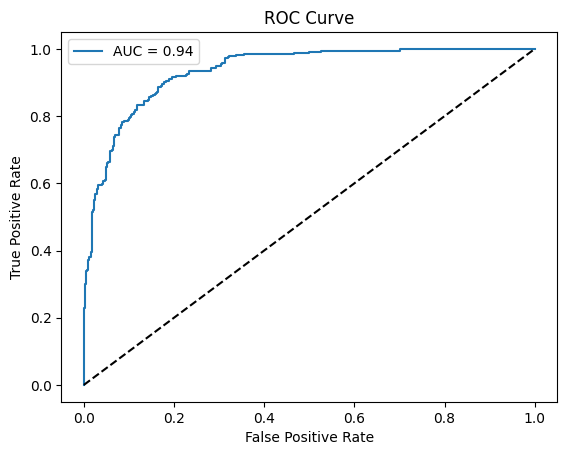

In [21]:
from sklearn.metrics import roc_curve, auc

y_probs = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_probs.extend(preds)

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [2]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Load model
model = tf.keras.models.load_model("best_model.h5")

# Prediction function
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        print("Non-Anemic")
    else:
        print("Anemic")

# Test image
predict_image(r"C:\Users\Sujal Pal\OneDrive\Desktop\New Deep Learning\CNN\archive (1)\Anemic\Anemic-260 (2).png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Non-Anemic
